In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df_eda = pd.read_csv('../Kaggle Challenges/auto-mpg/auto-mpg.csv', index_col=0)
df_eda.horsepower = pd.to_numeric(df_eda.horsepower, errors="coerce")
df_eda = pd.concat([df_eda, np.log(df_eda["mpg"]).rename("log_mpg")], axis=1)


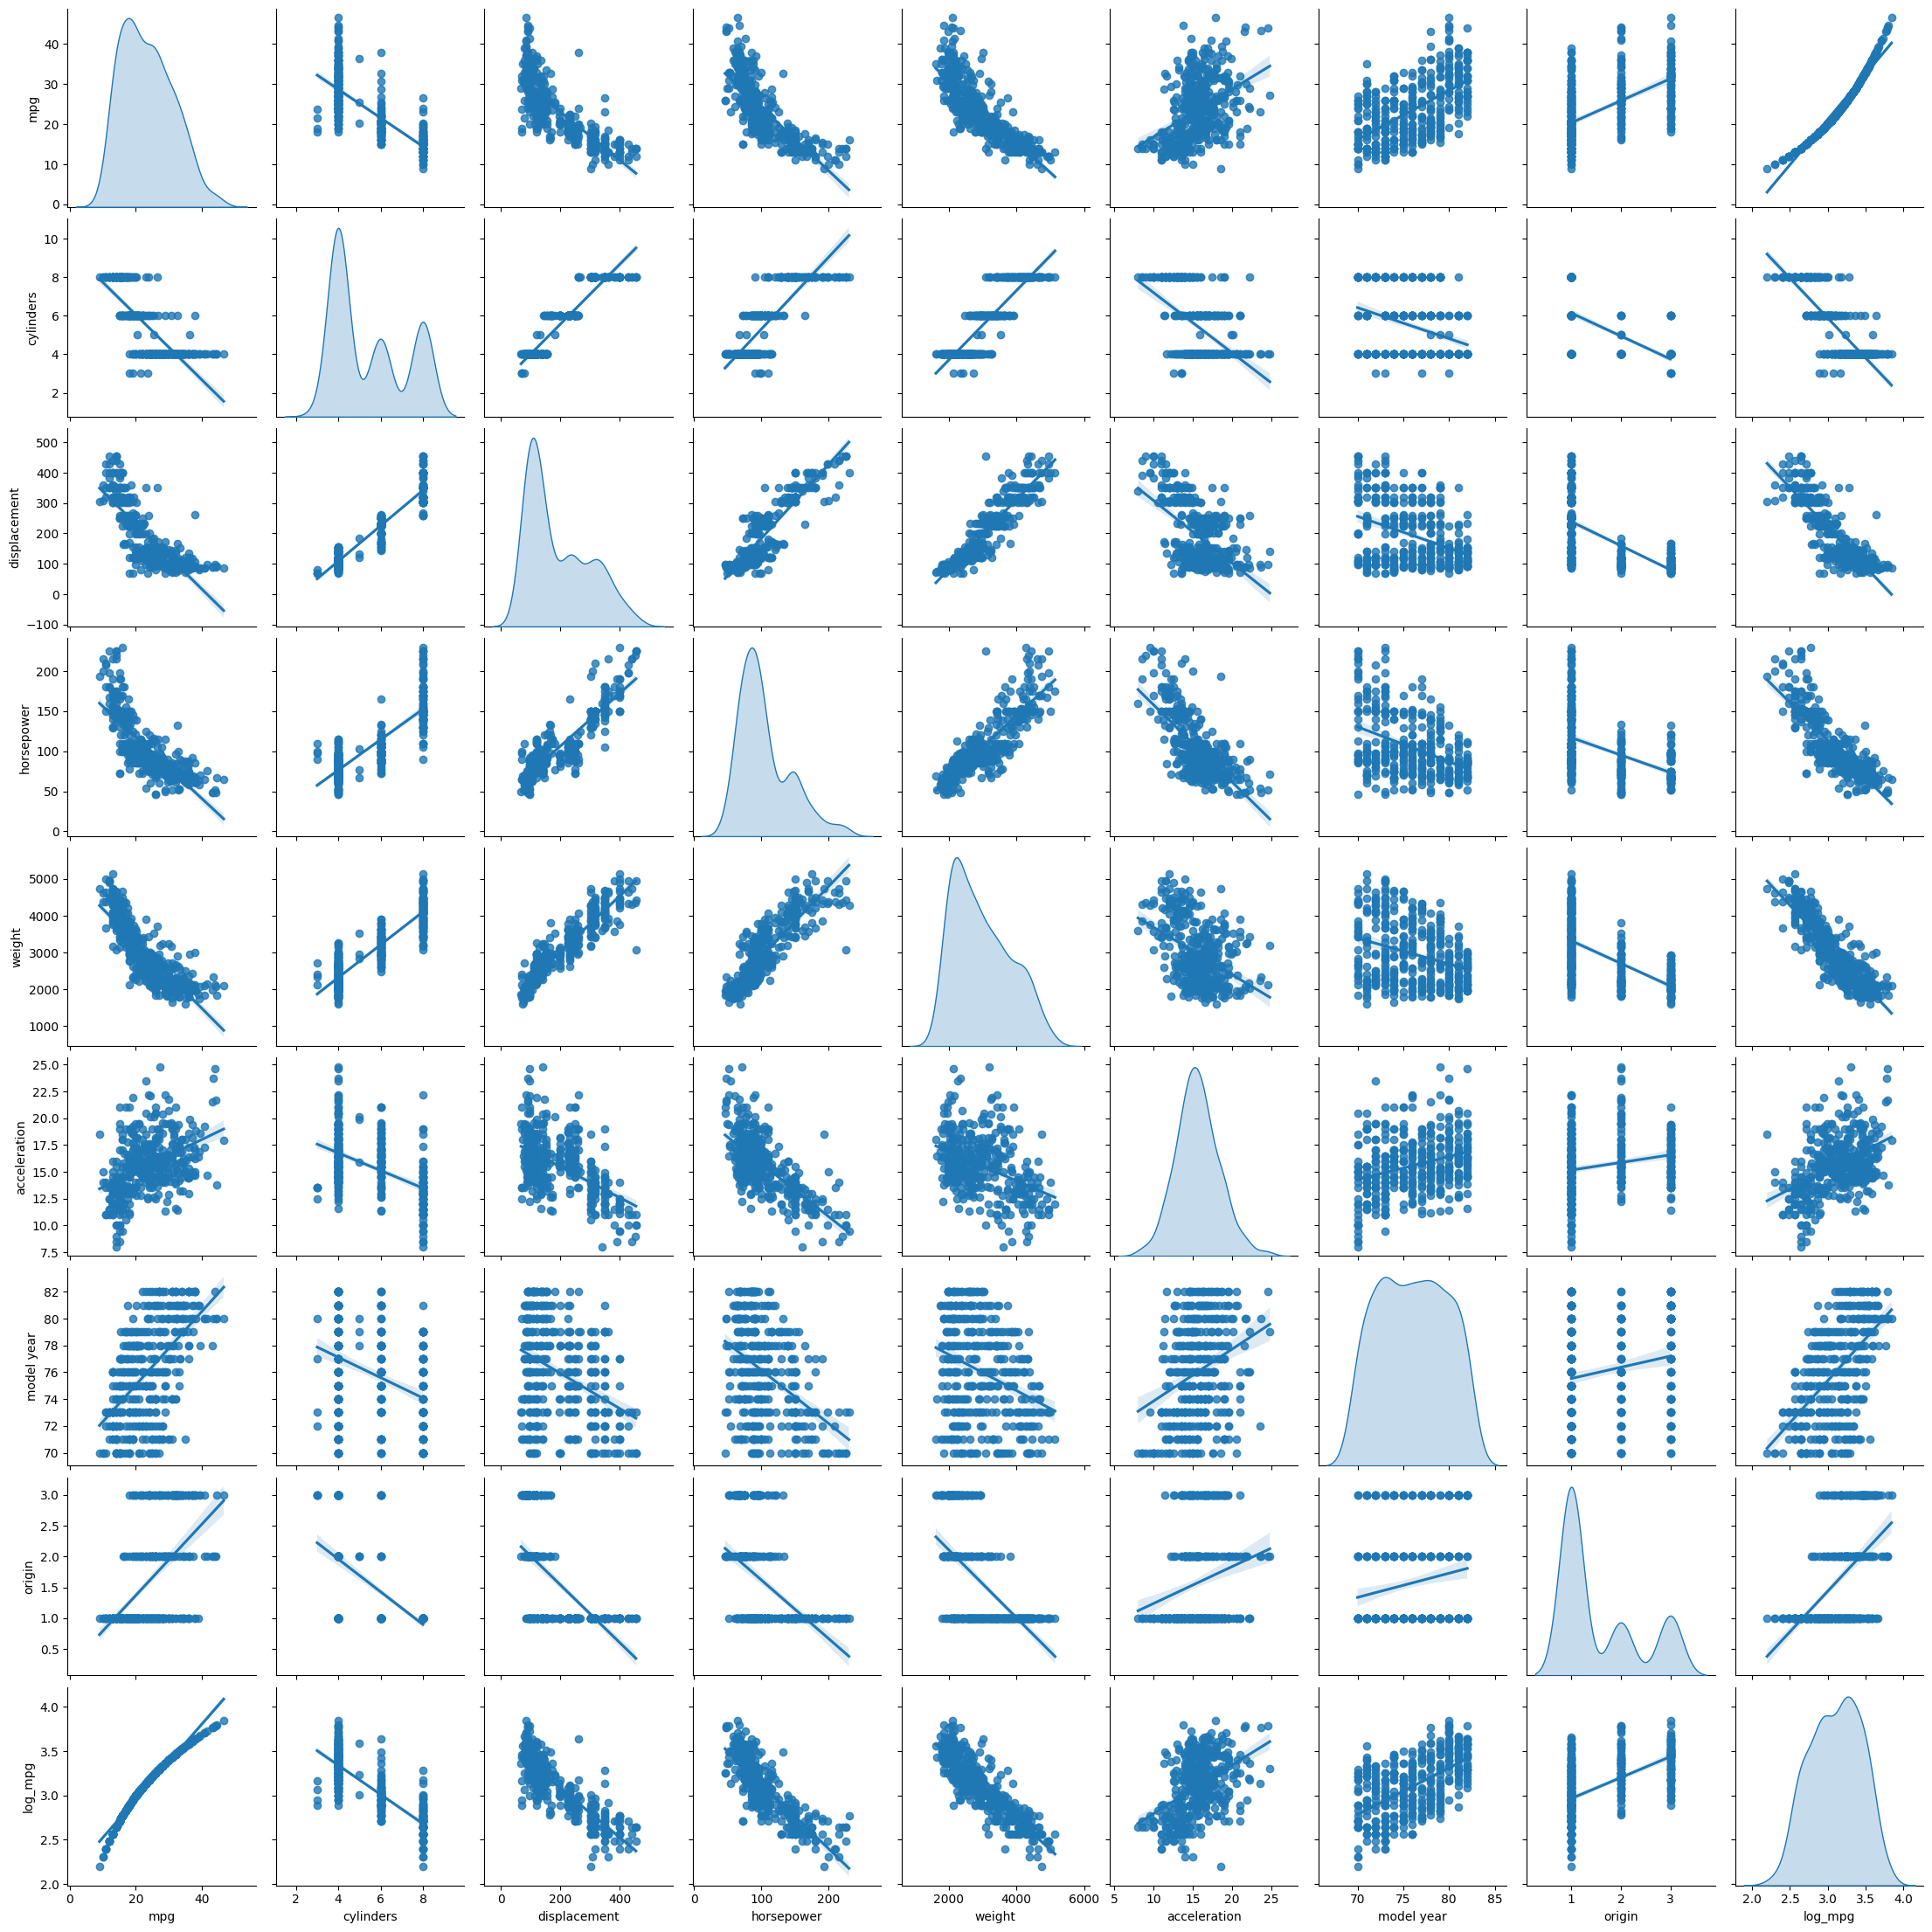

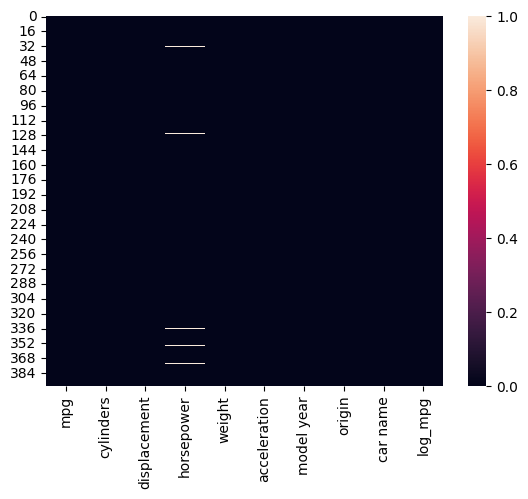

In [7]:
sns.pairplot(df_eda, diag_kind="kde", kind="reg")
plt.show()
sns.heatmap(df_eda.isna())
plt.show()

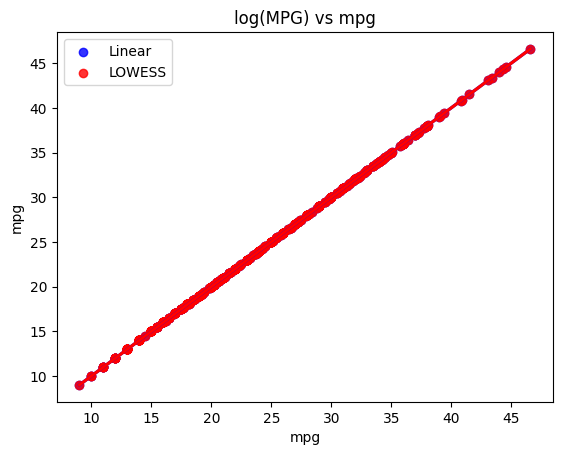

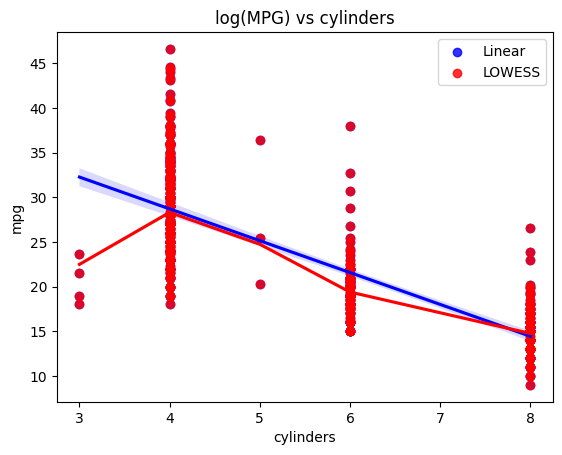

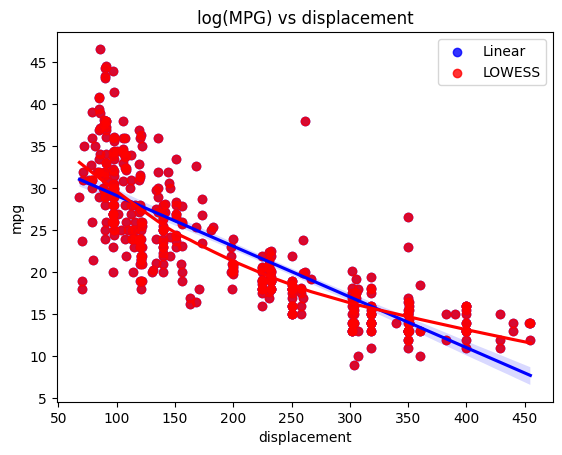

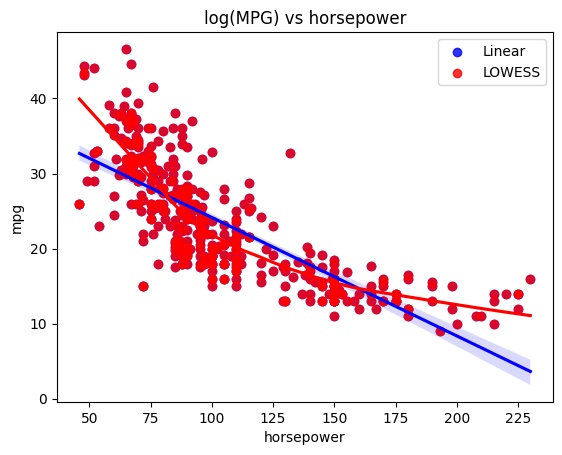

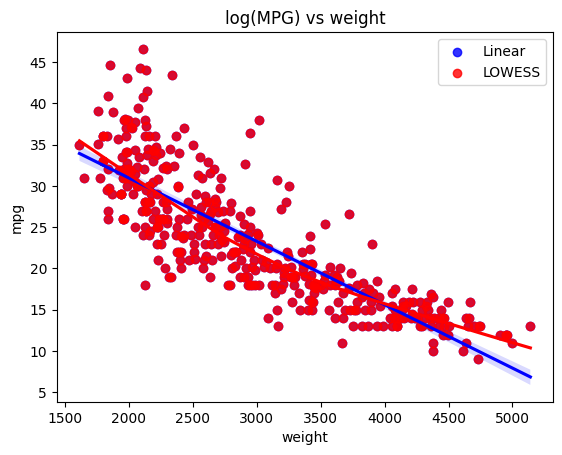

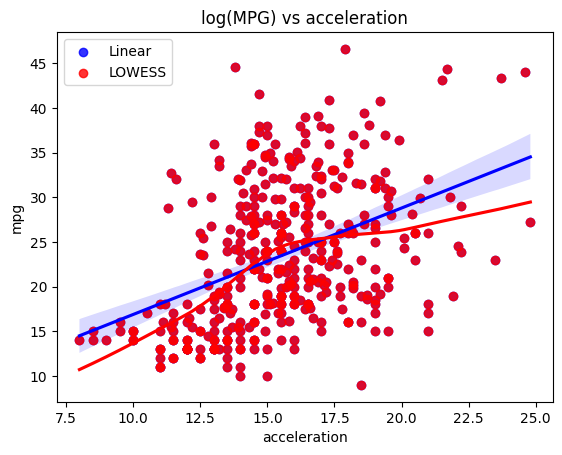

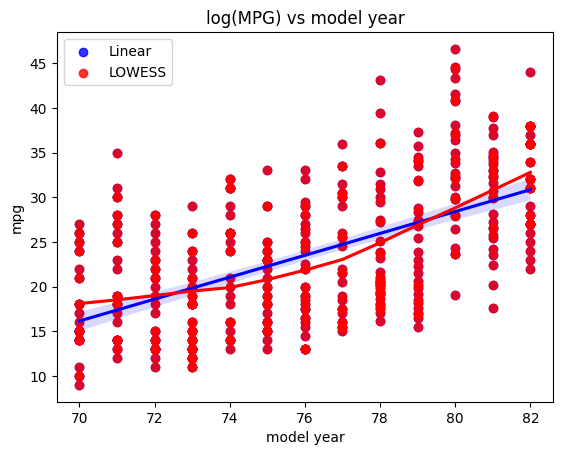

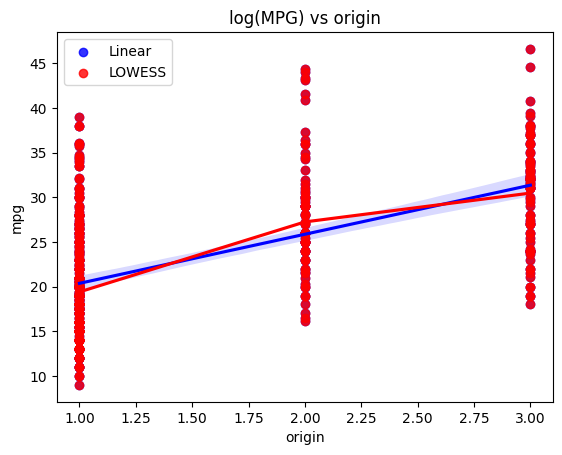

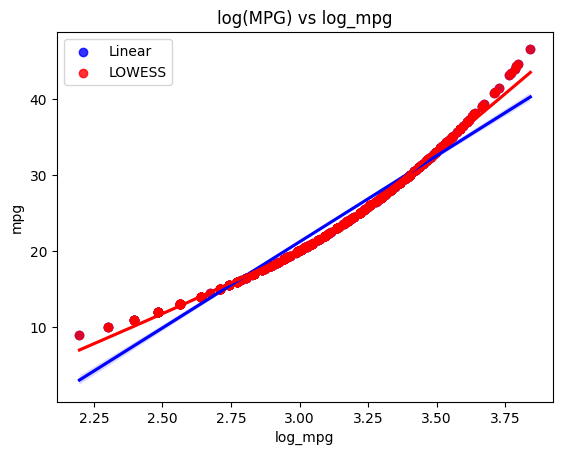

In [ ]:
# Regression plots for each numerical feature with both lowess and linear regression estimate
import matplotlib.pyplot as plt
import seaborn as sns

for feature in df_eda.select_dtypes("number").columns:
    # Linear regression line
    sns.regplot(x=feature, y="mpg", data=df_eda, scatter=True, label="Linear", color="blue")
    # LOWESS line
    sns.regplot(x=feature, y="mpg", data=df_eda, lowess=True, label="LOWESS", color="red")
    # Scatter plot (optional)
    #sns.scatterplot(x=feature, y="mpg", data=df_eda, alpha=0.5, color="gray")
    plt.title(f"log(MPG) vs {feature}")
    plt.legend()
    plt.show()

## Box-Cox Transformation Example

Optimal lambda found: -0.0391


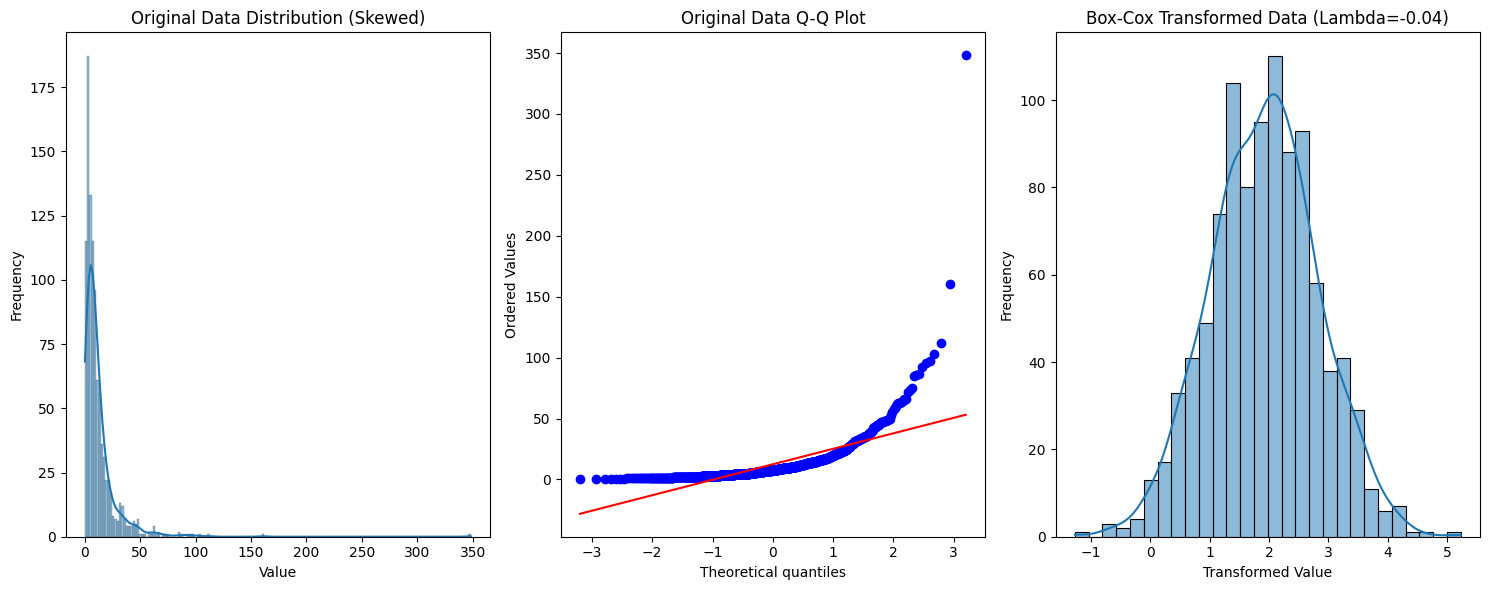

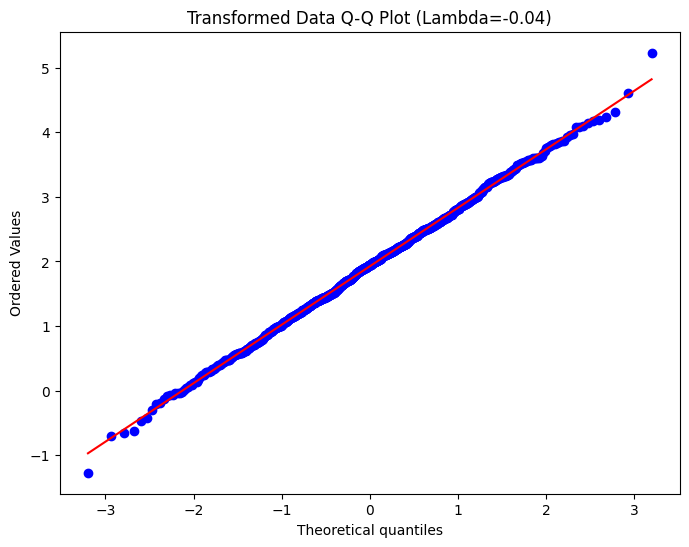

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import boxcox, norm, probplot
import seaborn as sns

# 1. Generate highly right-skewed data (e.g., from a log-normal distribution)
np.random.seed(42)
original_data = np.random.lognormal(mean=2, sigma=1.0, size=1000)

# 2. Plot the original data's histogram and Q-Q plot
plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
sns.histplot(original_data, kde=True)
plt.title('Original Data Distribution (Skewed)')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
probplot(original_data, dist="norm", plot=plt)
plt.title('Original Data Q-Q Plot')

# 3. Apply Box-Cox transformation
# boxcox returns the transformed data and the optimal lambda
transformed_data, lambda_ = boxcox(original_data)

print(f"Optimal lambda found: {lambda_:.4f}")

# 4. Plot the transformed data's histogram and Q-Q plot
plt.subplot(1, 3, 3)
sns.histplot(transformed_data, kde=True)
plt.title(f'Box-Cox Transformed Data (Lambda={lambda_:.2f})')
plt.xlabel('Transformed Value')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# You can also verify normality of transformed data with a Q-Q plot
plt.figure(figsize=(8, 6))
probplot(transformed_data, dist="norm", plot=plt)
plt.title(f'Transformed Data Q-Q Plot (Lambda={lambda_:.2f})')
plt.show()

# Model fit evaluation

In [ ]:
import statsmodels.api as sm
from scipy import stats
sm.qqplot(stats.zscore(glm.deviance_resid))

# Influence plot

In [ ]:
# Leverage plot
from statsmodels.graphics.regressionplots import plot_leverage_resid2
plot_leverage_resid2(Gamma_pca_results)

# Cooks distance on an individual observation

In [ ]:
Gamma_pca_influence = Gamma_pca_results.get_influence().summary_frame()

# Retrieve from X_train the most influential observations based on Cook's distance
influential_indices = Gamma_pca_influence.sort_values("cooks_d", ascending=False).head(10).index
influential_observations = X_train_pca.loc[influential_indices]